# This jupyter notebook is prepared by Fabrizzio Capocci.

# 1. Load Data and perform basic EDA

In [ ]:
# i. Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn import preprocessing

In [ ]:
# ii. Load the dataset and display number of rows and columns

df = pd.read_csv('hrdata2.csv')
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (8955, 15)


In [ ]:
# iii. Display first and last 5 rows

df.head()
df.tail()

,Unnamed: 0,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
8950,19147,21319,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,1.0,100-500,Pvt Ltd,1,52,1.0
8951,19149,251,city_103,0.920,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,50-99,Pvt Ltd,1,36,1.0
8952,19150,32313,city_160,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,10.0,100-500,Public Sector,3,23,0.0
8953,19152,29754,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,Humanities,7.0,10/49,Funded Startup,1,25,0.0
8954,19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,50-99,Pvt Ltd,4,44,0.0


In [ ]:
# iv. Show how many columns contain null values

print(df.isnull().sum())

Unnamed: 0                0
enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64


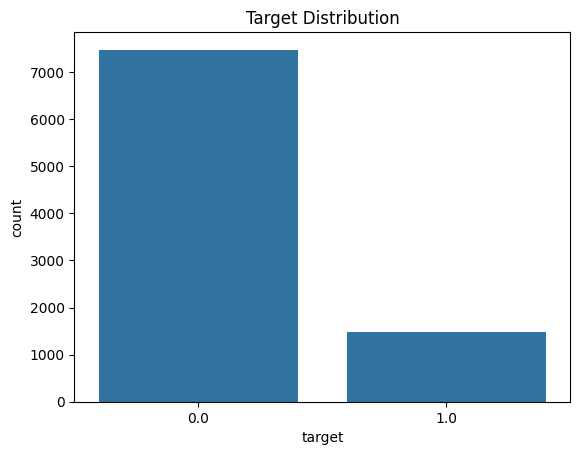

In [ ]:
# v. Plot the target distribution.

sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

# Discuss class imbalance, potential issues, and possible solutions:
# Class Imbalance: When a dataset has two classes that are not represented the same
# What are some of the issues?
## - Model can get biased toward majority class.
## - There is poor performance on minority class
# How can you solve class imbalance?
## - Resample the data with random sampling or SMOTE
## - Modify the algorithm to penalize mistakes on the minority class more heavilty



# 2. Feature Selection and Pre-processing
# I. Preprocessing city

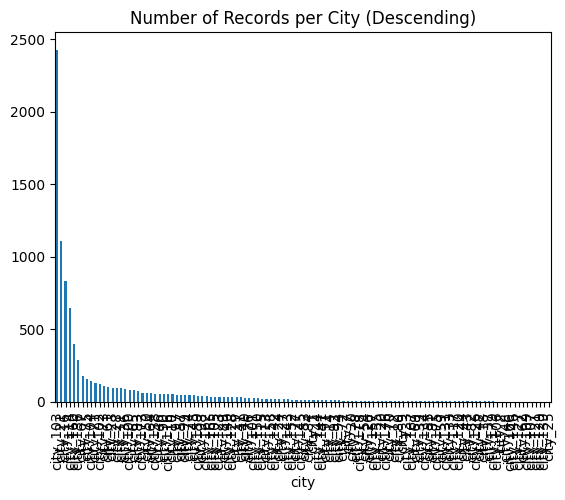

In [ ]:
# Plot # of records per city (descending)
city_counts = df['city'].value_counts()

city_counts.plot(kind='bar')
plt.title('Number of Records per City (Descending)')
plt.show()


In [ ]:
# II. Replace the city name with city_others if the city name is not within the top 4 city names.
top4_cities = city_counts.head(4).index

top4_count = df[df['city'].isin(top4_cities)].shape[0]
remaining_count = df[~df['city'].isin(top4_cities)].shape[0]

print("Top 4 cities total rows:", top4_count)
print("Remaining cities total rows:", remaining_count)

Top 4 cities total rows: 5021
Remaining cities total rows: 3934


In [ ]:
# III. Replace the city name with city_others if the city name is not within the top 4 city names.
df['city_updated'] = df['city'].apply(lambda x: x if x in top4_cities else 'city_others')

In [ ]:
# IV. Show sample rows to verify changes
df[['city', 'city_updated']].head()


,city,city_updated
0,city_40,city_others
1,city_162,city_others
2,city_46,city_others
3,city_103,city_103
4,city_103,city_103


# II. Education Level

In [ ]:
# I. Show the unique values of education level.
print(df['education_level'].unique())

['Graduate' 'Masters' 'Phd']


In [ ]:
# II. Convert the Education level column to ordinal values, like "Graduate" -> 0, Masters->1, and Phd -> 2
edu_map = {
    'Graduate': 0,
    'Masters': 1,
    'Phd': 2
}

df['education_level'] = df['education_level'].map(edu_map)

In [ ]:
# III. Show some sample data that the records have changed appropriately
df[['education_level']].head()

,education_level
0,0
1,1
2,0
3,0
4,0


# III. company_size column

In [ ]:
# I. Show the unique values of the company_size column
print(df['company_size'].unique())

['50-99' '<10' '5000-9999' '1000-4999' '10/49' '100-500' '10000+'
 '500-999']


In [ ]:
# II. Change the values of the company_size column to ordinal values from 0 to 7, where '<10' is 0 and '10000+' is 7.
size_map = {
    '<10': 0,
    '10/49': 1,
    '50-99': 2,
    '100-500': 3,
    '500-999': 4,
    '1000-4999': 5,
    '5000-9999': 6,
    '10000+': 7
}

df['company_size'] = df['company_size'].map(size_map)

In [ ]:
# III. Show the updated unique values
print(df['company_size'].unique())

[2 0 6 5 1 3 7 4]


# IV. Last_new_job

In [ ]:
# I. Show the unique values of the last_new_job column
print(df['last_new_job'].unique())

['>4' '4' '1' '3' '2' 'never']


In [ ]:
# II. Convert the values of this column to never->0, 1->1,....>4 -->5
def map_last_job(x):
    if x == 'never':
        return 0
    elif x == '>4':
        return 5
    else:
        return int(x)

df['last_new_job'] = df['last_new_job'].apply(map_last_job)

In [ ]:
# III. Show the updated values
print(df['last_new_job'].unique())

[5 4 1 3 2 0]


# V. Other Columns

In [ ]:
# I. Show the unique values of company_type, major_descipline, enrolled_university, relevant_experience, gender, and updated city column
cols = [
    'company_type',
    'major_discipline',
    'enrolled_university',
    'relevent_experience',
    'gender',
    'city_updated'
]

for col in cols:
    print(col, df[col].unique())

company_type ['Pvt Ltd' 'Funded Startup' 'Early Stage Startup' 'Public Sector' 'NGO'
 'Other']
major_discipline ['STEM' 'Humanities' 'Business Degree' 'Other' 'No Major' 'Arts']
enrolled_university ['no_enrollment' 'Part time course' 'Full time course']
relevent_experience ['No relevent experience' 'Has relevent experience']
gender ['Male' 'Female' 'Other']
city_updated ['city_others' 'city_103' 'city_114' 'city_21' 'city_16']


In [ ]:
# II. Use pandas' get_dummies function to create binary columns for the values of the following columns
df = pd.get_dummies(df, columns=cols)

# get_dummies is a pandas function that is used to convert categorical data into a one-hot encdoded columns directly to a dataframe.

# OneHotEncoder is a scikit-learn tool that is designed for machine learning workflows.

In [ ]:
# III. Show the top 5 and last 5 rows to show that the table has changed.
pd.set_option('display.max_columns', None)

df.head()
df.tail()

,Unnamed: 0,enrollee_id,city,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,gender_Female,gender_Male,gender_Other,city_updated_city_103,city_updated_city_114,city_updated_city_16,city_updated_city_21,city_updated_city_others
8950,19147,21319,city_21,0.624,0,1.0,3,1,52,1.0,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False,True,False,True,False,False,False,False,True,False
8951,19149,251,city_103,0.920,1,9.0,2,1,36,1.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,True,False,True,False,False,False,False
8952,19150,32313,city_160,0.920,0,10.0,3,3,23,0.0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False,True,False,False,False,False,False,False,True
8953,19152,29754,city_103,0.920,0,7.0,1,1,25,0.0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,True,False,False,True,False,False,False,False
8954,19155,24576,city_103,0.920,0,21.0,2,4,44,0.0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,True,False,True,False,False,False,False


In [ ]:
# IV. Also, show the shape of the table
print("Shape of dataset:", df.shape)

Shape of dataset: (8955, 35)


# VI. Drop the enrollee_id and any duplicate columns

In [ ]:
df.drop(columns=['enrollee_id', 'city'], inplace=True)

# VII. Feature Scaling

In [ ]:
# I. Use sklearn.preprocessing's MinMaxScaler to perform min max scaling to all the columns
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
# II. Show sample records that show some the scaled records
df_scaled.head()

,Unnamed: 0,city_development_index,education_level,experience,company_size,last_new_job,training_hours,target,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,gender_Female,gender_Male,gender_Other,city_updated_city_103,city_updated_city_114,city_updated_city_16,city_updated_city_21,city_updated_city_others
0,0.000000,0.654691,0.0,0.714286,0.285714,1.0,0.137313,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000157,0.636727,0.5,1.000000,0.285714,0.8,0.020896,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.000313,0.626747,0.0,0.619048,0.000000,1.0,0.050746,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.000365,0.942116,0.0,0.333333,0.285714,0.2,0.134328,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.000522,0.942116,0.0,0.238095,0.857143,0.2,0.319403,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


# VIII. Move the target column to the last column of the data frame and show that it has changed

In [ ]:
cols = list(df_scaled.columns)

cols.remove('target')
cols.append('target')

df_scaled = df_scaled[cols]

df_scaled.head()

,Unnamed: 0,city_development_index,education_level,experience,company_size,last_new_job,training_hours,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,enrolled_university_Full time course,enrolled_university_Part time course,enrolled_university_no_enrollment,relevent_experience_Has relevent experience,relevent_experience_No relevent experience,gender_Female,gender_Male,gender_Other,city_updated_city_103,city_updated_city_114,city_updated_city_16,city_updated_city_21,city_updated_city_others,target
0,0.000000,0.654691,0.0,0.714286,0.285714,1.0,0.137313,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.000157,0.636727,0.5,1.000000,0.285714,0.8,0.020896,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.000313,0.626747,0.0,0.619048,0.000000,1.0,0.050746,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.000365,0.942116,0.0,0.333333,0.285714,0.2,0.134328,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.000522,0.942116,0.0,0.238095,0.857143,0.2,0.319403,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# 3. X/Y and Training/Test Split with stratified sampling and SMOTE

In [ ]:
# I. Copy all the features into X and the target to Y
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']

In [ ]:
# II. Show the actual number and ratio of 1 and 0 in Y

print("Class counts in Y:")
print(y.value_counts().sort_index())

print("\nClass ratio in Y:")
print(y.value_counts(normalize=True).sort_index())

Ratio in Y:
target
0.0    0.834394
1.0    0.165606
Name: proportion, dtype: float64


In [ ]:
# III. Use sklearn's train_test_split to split the data set into training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

In [ ]:
# IV. Show the actual number and ratio of 1 and 0 in y_train and y_test

print("y_train class counts:")
print(y_train.value_counts().sort_index())

print("\ny_train class ratio:")
print(y_train.value_counts(normalize=True).sort_index())

print("\ny_test class counts:")
print(y_test.value_counts().sort_index())

print("\ny_test class ratio:")
print(y_test.value_counts(normalize=True).sort_index())

y_train ratio:
target
0.0    0.834397
1.0    0.165603
Name: proportion, dtype: float64

y_test ratio:
target
0.0    0.834388
1.0    0.165612
Name: proportion, dtype: float64


In [ ]:
# V. Rebalance:
# Use imblearn's SMOTE to balance the x_train

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# VI. Show the actual number and ratio of 0 and 1 after SMOTE

print("After SMOTE - class counts:")
print(pd.Series(y_train_res).value_counts().sort_index())

print("\nAfter SMOTE - class ratio:")
print(pd.Series(y_train_res).value_counts(normalize=True).sort_index())

After SMOTE (y_train_res ratio):
target
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64


# 4. PCA and Logistic Regression

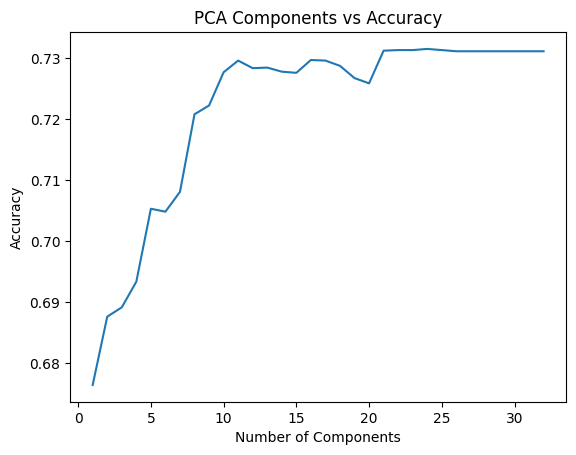

In [ ]:
# I.
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

accuracies = []
components = range(1, X_train_res.shape[1] + 1)

for n in components:
    pipeline = Pipeline([
        ('pca', PCA(n_components=n)),
        ('logreg', LogisticRegression(max_iter=1000))
    ])

    pipeline.fit(X_train_res, y_train_res)
    score = pipeline.score(X_train_res, y_train_res)
    accuracies.append(score)

# Plot results
plt.plot(components, accuracies)
plt.xlabel('Number of Components')
plt.ylabel('Accuracy')
plt.title('PCA Components vs Accuracy')
plt.show()

In [ ]:
# II.
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_pca, y_train_res)

y_pred = model.predict(X_test_pca)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8332713062895423


In [ ]:
# III.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1989  253]
 [ 195  250]]


# This confusion matrix shows that it is good at identifying negative cases. However, there are still a good amount of false positives and negatives.

# What we can derive from this is that while the CM is reasonably accurate, there is still improvement that can be made on it.

In [ ]:
# IV.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90      2242
         1.0       0.50      0.56      0.53       445

    accuracy                           0.83      2687
   macro avg       0.70      0.72      0.71      2687
weighted avg       0.84      0.83      0.84      2687



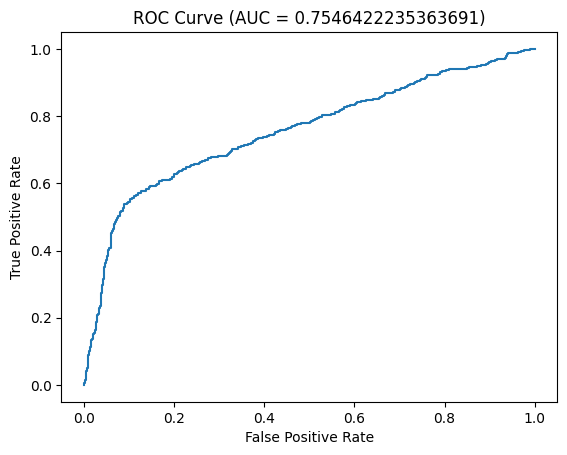

In [ ]:
# V.
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_pca)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {roc_auc})')
plt.show()

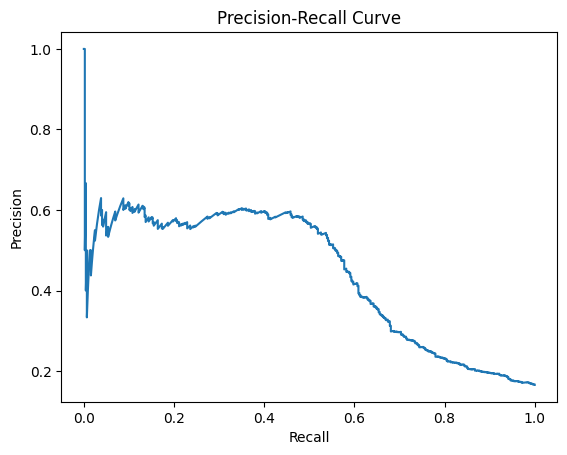

In [ ]:
# VI.
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

# 5. Softmax Regression

# 5a: The two are related because softmax is a generalization of logistic regression. Softmax expands on logistic regression because logistic is used for binary classification and softmax goes further with this idea and handles multiple classes using the softmax function.

# 5b. The number of weights and biases in the softmax model would be 44. I found this because the total number of weights is 40 (4 class multiplied by 10 features) and added it with the number of biases which is 4 (4 classes multiplied by 1 bias term)

# 6. KNN

In [ ]:
# I. Use sklearn's KNN classifier to train (with k=  10) and predict the model based on the unbalanced training set (the training set before rebalancing) and test it and show the confusion matrix and classification report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

# Train on original (unbalanced) training data
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Confusion Matrix
print("Confusion Matrix (Unbalanced):")
print(confusion_matrix(y_test, y_pred_knn))

# Classification Report
print("\nClassification Report (Unbalanced):")
print(classification_report(y_test, y_pred_knn))

Confusion Matrix (Unbalanced):
[[2155   87]
 [ 312  133]]

Classification Report (Unbalanced):
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.92      2242
         1.0       0.60      0.30      0.40       445

    accuracy                           0.85      2687
   macro avg       0.74      0.63      0.66      2687
weighted avg       0.83      0.85      0.83      2687



In [ ]:
# II. Use sklearn's KNN classifier to train (with k=  10) and predict the model based on the rebalanced training set and test it and show the confusion matrix and classification report

# Train on rebalanced data
knn_balanced = KNeighborsClassifier(n_neighbors=10)
knn_balanced.fit(X_train_res, y_train_res)

# Predict
y_pred_knn_balanced = knn_balanced.predict(X_test)

# Confusion Matrix
print("Confusion Matrix (Balanced):")
print(confusion_matrix(y_test, y_pred_knn_balanced))

# Classification Report
print("\nClassification Report (Balanced):")
print(classification_report(y_test, y_pred_knn_balanced))

Confusion Matrix (Balanced):
[[1701  541]
 [ 174  271]]

Classification Report (Balanced):
              precision    recall  f1-score   support

         0.0       0.91      0.76      0.83      2242
         1.0       0.33      0.61      0.43       445

    accuracy                           0.73      2687
   macro avg       0.62      0.68      0.63      2687
weighted avg       0.81      0.73      0.76      2687



In [ ]:
# III. Use grid search to tune the following hyperparameters of KNN: number of neighbors (between 1 and 20), weights  (uniform or distance), and metrics (Euclidean, Manhattan, or Minkowski distance) to use for KNN.

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

# Define parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Create KNN model
knn = KNeighborsClassifier()

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'AUC': 'roc_auc'
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scoring,
    refit='AUC',
    cv=5
)

# Fit using rebalanced training set
grid_search.fit(X_train_res, y_train_res)

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}


In [ ]:
# IV. After completing the process, print the best_params_
print("Best Parameters from Grid Search:")
print(grid_search.best_params_)

Best Parameters from Grid Search:
{'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}


In [ ]:
# V. Based on the result from grid search, use the parameters to train a model, test it with test set, and then print the confusion matrix and classification report. Also, show the AUC of ROC.

from sklearn.metrics import roc_auc_score

# Train model with best parameters
best_knn = grid_search.best_estimator_

# Predict
y_pred_best = best_knn.predict(X_test)
y_prob_best = best_knn.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("Confusion Matrix (Best Model):")
print(confusion_matrix(y_test, y_pred_best))

# Classification Report
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best))

# AUC
auc_score = roc_auc_score(y_test, y_prob_best)
print("\nAUC Score:", auc_score)

Confusion Matrix (Best Model):
[[1798  444]
 [ 193  252]]

Classification Report (Best Model):
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85      2242
         1.0       0.36      0.57      0.44       445

    accuracy                           0.76      2687
   macro avg       0.63      0.68      0.65      2687
weighted avg       0.81      0.76      0.78      2687


AUC Score: 0.7196579097715724


In [ ]:


# VI. Use PCA and, based on the best setup found by the gridsearch, test it and then print the confusion matrix and classification report. Also, show the AUC of ROC

from sklearn.decomposition import PCA

# Apply PCA (use same number of components as your chosen best setup)
pca = PCA(n_components=10)  # replace 10 if needed

X_train_pca = pca.fit_transform(X_train_res)
X_test_pca = pca.transform(X_test)

# Train best KNN model using PCA data
best_knn_pca = KNeighborsClassifier(**grid_search.best_params_)
best_knn_pca.fit(X_train_pca, y_train_res)

# Predict
y_pred_pca = best_knn_pca.predict(X_test_pca)
y_prob_pca = best_knn_pca.predict_proba(X_test_pca)[:, 1]

# Confusion Matrix
print("Confusion Matrix (PCA Model):")
print(confusion_matrix(y_test, y_pred_pca))

# Classification Report
print("\nClassification Report (PCA Model):")
print(classification_report(y_test, y_pred_pca))

# AUC
auc_pca = roc_auc_score(y_test, y_prob_pca)
print("\nAUC Score (PCA Model):", auc_pca)

Confusion Matrix (PCA Model):
[[1722  520]
 [ 190  255]]

Classification Report (PCA Model):
              precision    recall  f1-score   support

         0.0       0.90      0.77      0.83      2242
         1.0       0.33      0.57      0.42       445

    accuracy                           0.74      2687
   macro avg       0.61      0.67      0.62      2687
weighted avg       0.81      0.74      0.76      2687


AUC Score (PCA Model): 0.7184025097976325


### 6-vii. Discussion of the Four KNN Models

The first KNN model was trained using the original unbalanced training data. Because the dataset contains more observations from the majority class, this model may favor the majority class and may have weaker performance when identifying candidates who are looking for a job change.

The second KNN model was trained using the SMOTE-rebalanced training data. Balancing the training set gives the classifier more opportunity to learn patterns associated with the minority class. This can improve recall for the positive class, although it can also increase the number of false positives.

The third model used GridSearchCV to find the best combination of the number of neighbors, distance metric, and weighting method. This model should generally provide better performance than using an arbitrary value of k because its hyperparameters were selected using cross-validation and AUC.

The fourth model combined PCA with the best KNN hyperparameters. PCA reduced the number of features before KNN was applied. This can reduce dimensionality and potentially remove redundant information, but reducing the number of features can also remove information that is useful for classification.

Overall, the balanced KNN models are more appropriate for this imbalanced dataset because they give the classifier a better opportunity to identify both classes. The best model should be selected based on metrics such as AUC, precision, recall, and F1-score rather than accuracy alone.

# 7. Naive Bayes

GaussianNB Confusion Matrix:
[[1053 1189]
 [ 107  338]]

GaussianNB Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.47      0.62      2242
         1.0       0.22      0.76      0.34       445

    accuracy                           0.52      2687
   macro avg       0.56      0.61      0.48      2687
weighted avg       0.79      0.52      0.57      2687



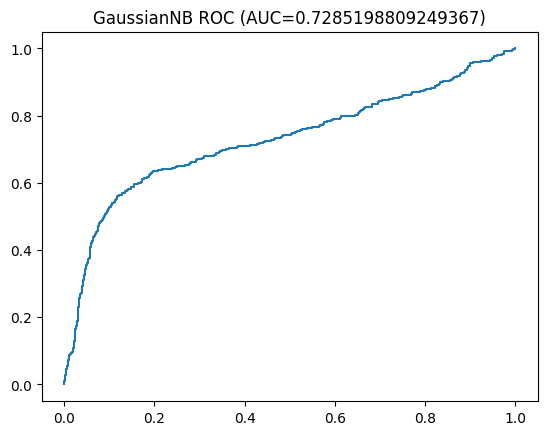

Misclassifications: 1296


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# Train
gnb = GaussianNB()
gnb.fit(X_train_res, y_train_res)

# Predict
y_pred_gnb = gnb.predict(X_test)
y_prob_gnb = gnb.predict_proba(X_test)[:, 1]

# Confusion Matrix
print("GaussianNB Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))

# Classification Report
print("\nGaussianNB Classification Report:")
print(classification_report(y_test, y_pred_gnb))

# ROC & AUC
fpr, tpr, _ = roc_curve(y_test, y_prob_gnb)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"GaussianNB ROC (AUC={auc_score})")
plt.show()

# Misclassifications
print("Misclassifications:", (y_test != y_pred_gnb).sum())

CategoricalNB Confusion Matrix:
[[1901  341]
 [ 206  239]]

CategoricalNB Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.85      0.87      2242
         1.0       0.41      0.54      0.47       445

    accuracy                           0.80      2687
   macro avg       0.66      0.69      0.67      2687
weighted avg       0.82      0.80      0.81      2687



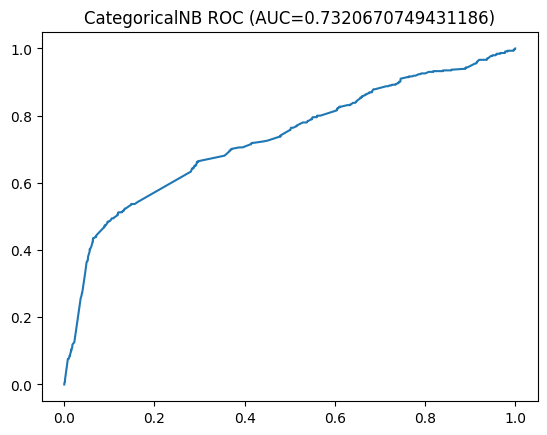

Misclassifications: 547


In [ ]:
from sklearn.naive_bayes import CategoricalNB

cnb = CategoricalNB()
cnb.fit(X_train_res, y_train_res)

y_pred_cnb = cnb.predict(X_test)
y_prob_cnb = cnb.predict_proba(X_test)[:, 1]

print("CategoricalNB Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_cnb))

print("\nCategoricalNB Classification Report:")
print(classification_report(y_test, y_pred_cnb))

fpr, tpr, _ = roc_curve(y_test, y_prob_cnb)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"CategoricalNB ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_cnb).sum())

# 8. Support Vector Machine

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(probability=True), param_grid, cv=5)
grid.fit(X_train_res, y_train_res)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


# 9. Decision Tree

[[2111  131]
 [ 286  159]]
              precision    recall  f1-score   support

         0.0       0.88      0.94      0.91      2242
         1.0       0.55      0.36      0.43       445

    accuracy                           0.84      2687
   macro avg       0.71      0.65      0.67      2687
weighted avg       0.83      0.84      0.83      2687



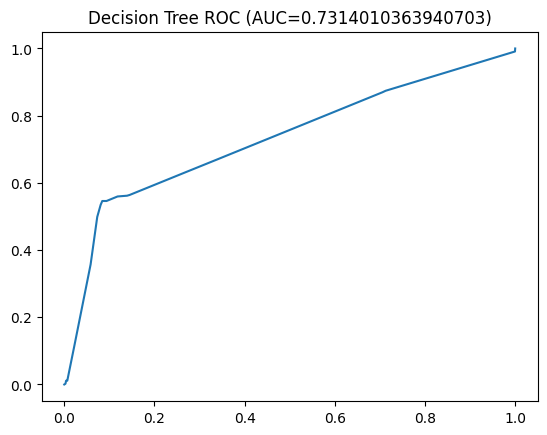

Misclassifications: 417


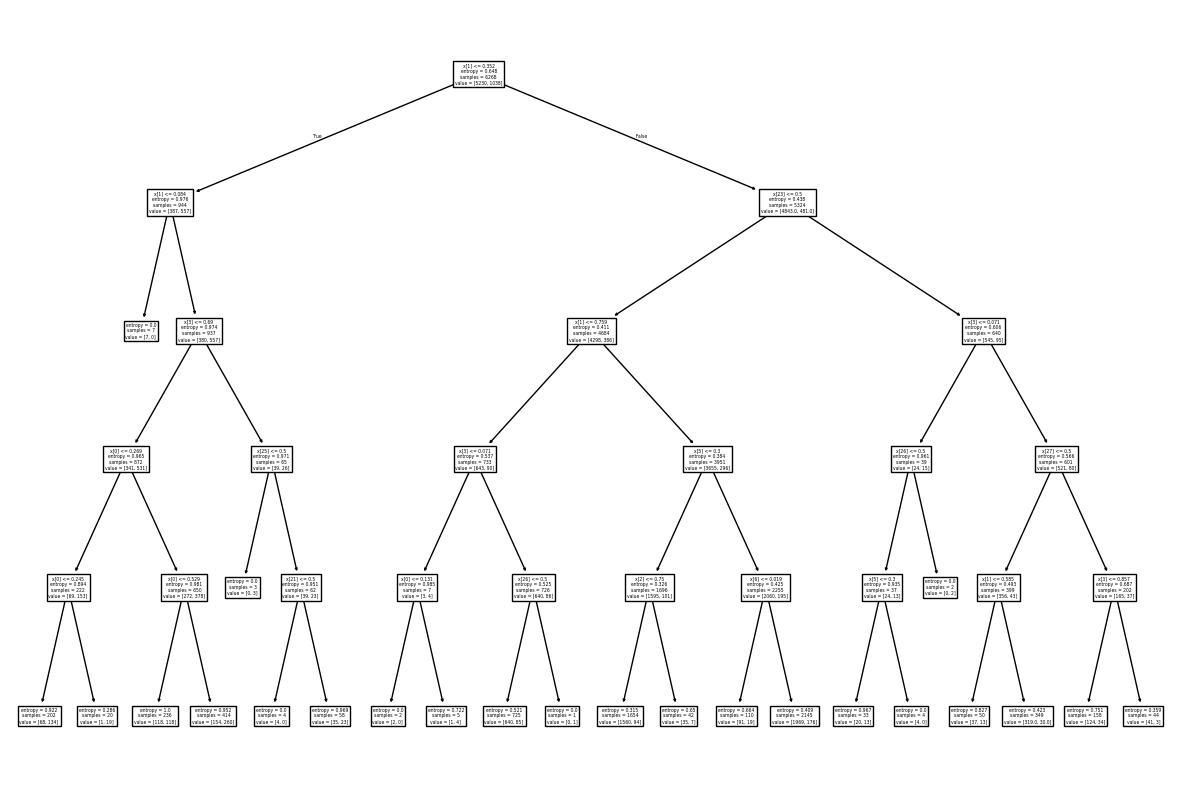

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Decision Tree ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_dt).sum())

# Plot tree
plt.figure(figsize=(15,10))
plot_tree(dt)
plt.show()

[[2037  205]
 [ 207  238]]
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      2242
         1.0       0.54      0.53      0.54       445

    accuracy                           0.85      2687
   macro avg       0.72      0.72      0.72      2687
weighted avg       0.85      0.85      0.85      2687



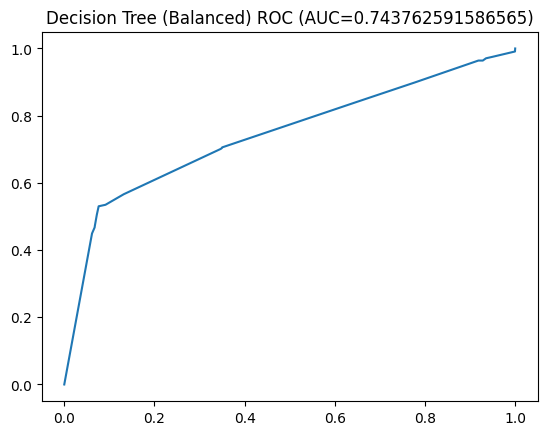

Misclassifications: 412


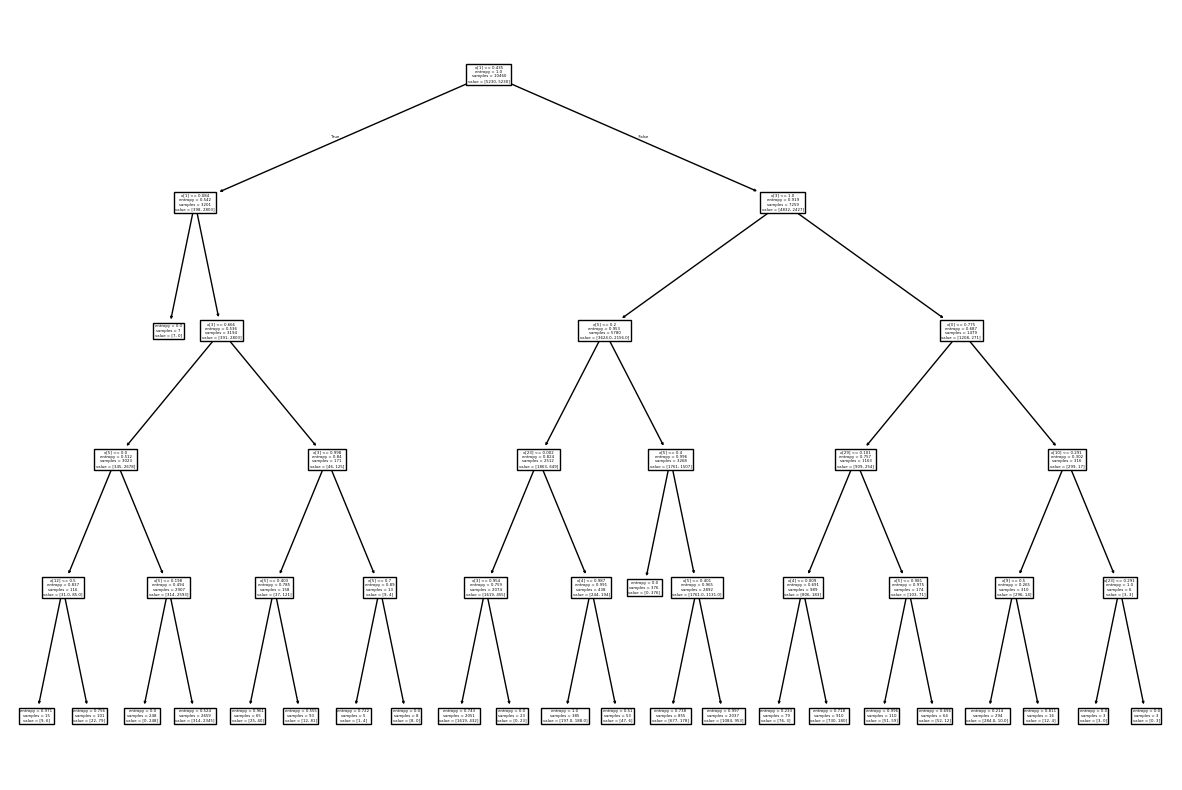

In [ ]:
dt_bal = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt_bal.fit(X_train_res, y_train_res)

y_pred_dt_bal = dt_bal.predict(X_test)
y_prob_dt_bal = dt_bal.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_dt_bal))
print(classification_report(y_test, y_pred_dt_bal))

fpr, tpr, _ = roc_curve(y_test, y_prob_dt_bal)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Decision Tree (Balanced) ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_dt_bal).sum())

plt.figure(figsize=(15,10))
plot_tree(dt_bal)
plt.show()

# The main difference between the two trees is that the decision tree trained on a unbalanced dataset. In the unbalanced tree, the model is biased towards the majority class. In the balanced tree, the model is created using SMOT, which shows a morer even distribution. Overall, the balanced tree produces a more fiar model.

# 10. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_rf.fit(X_train_res, y_train_res)

print("Best Estimator:", grid_rf.best_estimator_)

Best Estimator: RandomForestClassifier(max_depth=10)


[[2059  183]
 [ 206  239]]
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.57      0.54      0.55       445

    accuracy                           0.86      2687
   macro avg       0.74      0.73      0.73      2687
weighted avg       0.85      0.86      0.85      2687



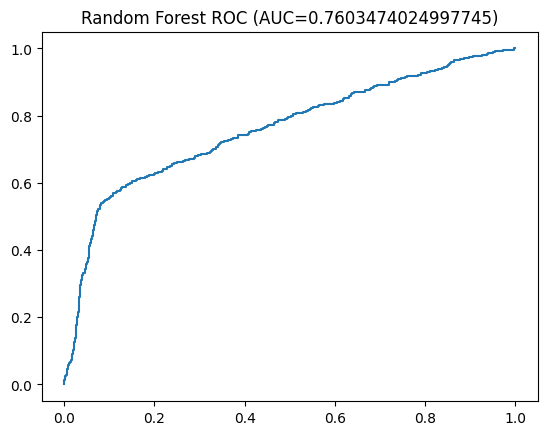

Misclassifications: 389


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Random Forest ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_rf).sum())

# 11. Boosting Algortihms

[[2053  189]
 [ 201  244]]
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.56      0.55      0.56       445

    accuracy                           0.85      2687
   macro avg       0.74      0.73      0.73      2687
weighted avg       0.85      0.85      0.85      2687



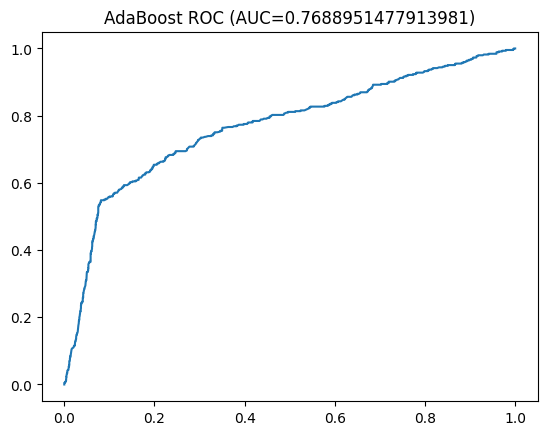

Misclassifications: 390


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)
ada.fit(X_train_res, y_train_res)

y_pred_ada = ada.predict(X_test)
y_prob_ada = ada.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

fpr, tpr, _ = roc_curve(y_test, y_prob_ada)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"AdaBoost ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_ada).sum())

[[2066  176]
 [ 214  231]]
              precision    recall  f1-score   support

         0.0       0.91      0.92      0.91      2242
         1.0       0.57      0.52      0.54       445

    accuracy                           0.85      2687
   macro avg       0.74      0.72      0.73      2687
weighted avg       0.85      0.85      0.85      2687



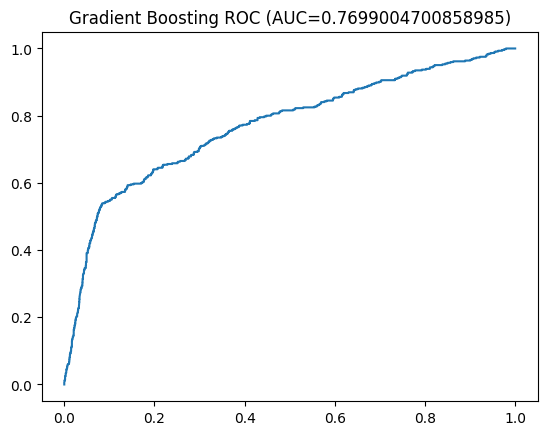

Misclassifications: 390


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

fpr, tpr, _ = roc_curve(y_test, y_prob_gb)
auc_score = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title(f"Gradient Boosting ROC (AUC={auc_score})")
plt.show()

print("Misclassifications:", (y_test != y_pred_gb).sum())

# 12. Final Discussion

# Based on the results, gradient boosting appears to be the most efficent. It achieves the highest f1 score for the positive class. This is important because the dataset is imbalanced. It also is slightly better in its precision score (better at getting FP and FN). The worst performing was random forest, while KNN and naive bayes did relatively well. The decision tree overfitted the model.

# For future projects, better work can be done by performing hyperparameter tuning, and also trying more advanced boosting techniques.